In [4]:
from pathlib import Path

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import torchvision.transforms as v1
from torchvision.io import decode_image

plt.rcParams["savefig.bbox"] = 'tight'
torch.manual_seed(1)

# If you're trying to run that on Colab, you can download the assets and the
# helpers from https://github.com/pytorch/vision/tree/main/gallery/
import sys
sys.path += ["../transforms"]
from transforms.helpers import plot
ASSETS_PATH = Path('./assets')

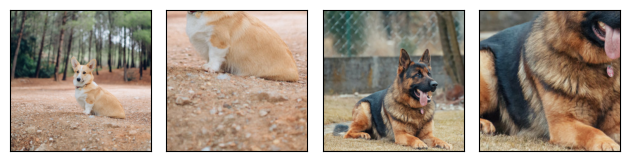

In [5]:
dog1 = decode_image(str(ASSETS_PATH / 'dog1.jpg'))
dog2 = decode_image(str(ASSETS_PATH / 'dog2.jpg'))

transforms = torch.nn.Sequential(
    v1.RandomCrop(224),
    v1.RandomHorizontalFlip(p=0.3),
)

scripted_transforms = torch.jit.script(transforms)

plot([dog1, scripted_transforms(dog1), dog2, scripted_transforms(dog2)])

In [6]:
from torchvision.models import resnet18, ResNet18_Weights


class Predictor(nn.Module):

    def __init__(self):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT
        self.resnet18 = resnet18(weights=weights, progress=False).eval()
        self.transforms = weights.transforms(antialias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            x = self.transforms(x)
            y_pred = self.resnet18(x)
            return y_pred.argmax(dim=1)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

predictor = Predictor().to(device)
scripted_predictor = torch.jit.script(predictor).to(device)

batch = torch.stack([dog1, dog2]).to(device)

res = predictor(batch)
res_scripted = scripted_predictor(batch)

In [9]:
import json

with open(Path('./assets') / 'imagenet_class_index.json') as labels_file:
    labels = json.load(labels_file)

for i, (pred, pred_scripted) in enumerate(zip(res, res_scripted)):
    assert pred == pred_scripted
    print(f"Prediction for Dog {i + 1}: {labels[str(pred.item())]}")

Prediction for Dog 1: ['n02113023', 'Pembroke']
Prediction for Dog 2: ['n02106662', 'German_shepherd']


In [ ]:
import tempfile

with tempfile.NamedTemporaryFile() as f:
    scripted_predictor.save(f.name)

    dumped_scripted_predictor = torch.jit.load(f.name)
    res_scripted_dumped = dumped_scripted_predictor(batch)
assert (res_scripted_dumped == res_scripted).all()